# Flood · Solar — M0: solar site selection, geometry, depth & coastal/all-three (all solar sites)

**Magnitude metric:** the M0 screening metrics — FEMA **SFHA membership** (riverine), NOAA **CFEM surge-onset
hurricane category** (coastal), and ground **elevation (m, NAVD88)** for the depth side of coupling; per-RP / per-
storm flood **depth (ft above ground)** is the M1 hazard input.

**Data source:** **EIA-860** 2024 solar fleet (screen population) · FEMA **NFHL** flood zones · USGS **3DEP**
elevation · **OSM** Overpass `power=plant` footprints (real polygons; circle fallback) · FEMA **BLE** depth
(coverage probe) · NOAA **CFEM** coastal-surge composite.

**What this notebook does:** locks every **solar** flood site and meets its evidence, in four sections: **(1)** screen
the national EIA-860 solar fleet by NFHL SFHA → the inland riverine sites (Hayhurst dry baseline + Elizabeth);
**(2)** their 3DEP DEM ground elevation, footprint geometry & FEMA flood-zone context; **(3)** screen the
Gulf/Atlantic fleet by CFEM surge onset → the coastal site (Discovery); **(4)** register the all-three site
(LA3 West Baton Rouge). Emits the solar rosters `flood_solar_m0_sites.json` (inland), `flood_solar_m0_dem_context.json`, and
`flood_solar_coastal_m0_sites.json` (coastal), plus the screen-audit CSVs — the shared input M1 reads.

## ═══ part 1/4 ═══  Flood · Riverine `[R]` × Solar — M0: site screen + geometry (the two inland solar sites)

**Magnitude metric:** the M0 **screening metric** is FEMA **SFHA membership** (is the site in the 1%-annual-chance
floodplain?) — a yes/no flood-exposure proxy; the loss-driving **depth (ft above ground)** at each return period
comes downstream in M1.

**Data source:** **EIA-860** 2024 operating solar fleet (the screen population, lat/lon/MW per plant) ∩ FEMA
**NFHL** flood-hazard zones (layer 28) at each plant centroid and a capacity-radius buffer; geometry is a
**capacity→radius circle** here (a real OSM polygon + BLE depth refine the high pick in `02`/M1).

**What this notebook does:** locks the two inland solar sites as a low-vs-high flood contrast. It reuses **Hayhurst
Texas Solar** (EIA 66880, Culberson Co. TX) as the dry baseline — same asset as hail + wildfire for cross-peril
coherence — and screens the EIA-860 national solar fleet, restricted to Lower-Mississippi utility-scale plants
(LA/MS/AR, ≥20 MW per JD-FL-3), by FEMA NFHL SFHA membership. A geometry + BLE refinement over the top exposed
candidates picks **Elizabeth Solar** (EIA 66111, Allen Parish LA, 143 MW) as the high site — it carries a real
~3.9 km² OSM polygon and the deepest BLE flood of the polygon-bearing candidates. Known-answer checks confirm
Hayhurst reads not-SFHA (dry baseline) and Elizabeth reads flood-exposed; outputs are the two-site manifest
(`flood_solar_m0_sites.json`) and the screen audit CSV that feed `02` and M1.

| role | asset | where | screen metric |
|---|---|---|---|
| **baseline (low-flood)** | **Hayhurst Texas Solar** (EIA 66880) | Culberson Co., **TX** — Chihuahuan desert | **no mapped flood** (true zero) |
| **proving (high-flood)** | **Elizabeth Solar** (EIA 66111) | Allen Parish, **LA** — Lower-Mississippi plain | FEMA **SFHA** in footprint + BLE depth |

> **Public, self-serve data.** The screen runs on **EIA-860 ∩ FEMA NFHL** (national fleet × SFHA membership); the
> high site is confirmed by **FEMA BLE** depth ([JD-FL-6](../../../docs/plans/flood/decisions.md)). Real **OSM
> `power=plant` polygons** are fetched for both sites in part 2 (the enriched-registry polygon remains an optional
> one-place swap via the loader seam). Loss-driving depth is built in M1 from the BLE raster — Fathom is only a
> future commercial swap-in.
>
> Plan: [`m0_input_data.md`](../../../docs/plans/flood/m0_input_data.md) · Decisions:
> [`decisions.md`](../../../docs/plans/flood/decisions.md) (JD-FL-1..4).

In [1]:
import io, json, math, re, time, zipfile, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import requests
from shapely.geometry import Point, shape
from shapely import wkt as _wkt
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent

RAW = ROOT / "data" / "flood" / "raw"
OUT = ROOT / "data" / "flood"

# --- tiny HTTP file-cache: memoize JSON responses → deterministic, flaky-endpoint-robust re-runs ---
_CACHE = OUT / "raw" / "http_cache"; _CACHE.mkdir(parents=True, exist_ok=True)
def cget(url, params=None, post=False, timeout=40):
    key = hashlib.md5((("P" if post else "G") + url + json.dumps(params, sort_keys=True, default=str)).encode()).hexdigest()
    f = _CACHE / (key + ".json")
    if f.exists():
        return json.loads(f.read_text())
    r = requests.post(url, data=params, timeout=timeout) if post else requests.get(url, params=params, timeout=timeout)
    j = r.json(); f.write_text(json.dumps(j)); return j
# ---------------------------------------------------------------------------------------------------
RAW.mkdir(parents=True, exist_ok=True)
print("repo root:", ROOT)

# EIA-860 2024 annual (public, no key). The Plant sheet carries lat/lon; 3_3_Solar the solar generators.
EIA_URL = "https://www.eia.gov/electricity/data/eia860/xls/eia8602024.zip"
EIA_ZIP = RAW / "eia860_2024.zip"
if not EIA_ZIP.exists():
    print("downloading EIA-860 2024 …")
    EIA_ZIP.write_bytes(requests.get(EIA_URL, timeout=180).content)
print("EIA-860 zip:", EIA_ZIP, f"({EIA_ZIP.stat().st_size/1e6:.1f} MB)")

repo root: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling
EIA-860 zip: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/raw/eia860_2024.zip (22.1 MB)


## 1 · The national solar fleet (EIA-860)

Aggregate **operating** solar generators to plant level (total nameplate MW), join the Plant sheet for
lat/lon/state/county. This is the screen population — the same role `powerplants_enriched_v2` played for wildfire.

In [2]:
with zipfile.ZipFile(EIA_ZIP) as z:
    with z.open("2___Plant_Y2024.xlsx") as f:
        plant = pd.read_excel(f, skiprows=1)
    with z.open("3_3_Solar_Y2024.xlsx") as f:
        solar = pd.read_excel(f, skiprows=1)

solar["Nameplate Capacity (MW)"] = pd.to_numeric(solar["Nameplate Capacity (MW)"], errors="coerce")
solar_op = solar[solar["Status"] == "OP"]
cap = solar_op.groupby("Plant Code")["Nameplate Capacity (MW)"].sum().rename("solar_mw")

fleet = (plant.set_index("Plant Code")
              .join(cap, how="inner")
              .reset_index()
              .dropna(subset=["Latitude", "Longitude"]))
fleet = fleet[["Plant Code", "Plant Name", "State", "County", "solar_mw", "Latitude", "Longitude"]]
print(f"operating solar plants nationwide: {len(fleet):,}  |  total {fleet['solar_mw'].sum():,.0f} MW")
fleet.sort_values("solar_mw", ascending=False).head(5)

operating solar plants nationwide: 6,489  |  total 124,301 MW


,Plant Code,Plant Name,State,County,solar_mw,Latitude,Longitude
3579,63352,Gemini Solar Hybrid,NV,Clark,690.0,36.4678,-114.806
5525,66624,Double Back Diamond,IL,Sangamon,592.8,39.53729,-89.809783
215,57695,Topaz Solar Farm,CA,San Luis Obispo,585.9,35.405556,-120.068611
5849,67239,Fox Squirrel Solar,OH,Madison,577.0,39.777493,-83.367069
4159,64233,Hecate Energy Frye Solar LLC,TX,Swisher,500.0,34.4067,-101.59661


## 2 · Restrict to the screen region (Lower-Mississippi: LA / MS / AR), utility-scale

JD-FL-3 targets the Lower-Mississippi alluvial plain — deep, frequent riverine flooding and the best public
depth-grid coverage. Keep utility-scale (≥ 20 MW) so the high site is a peer of Hayhurst's class.

In [3]:
UTIL_MW = 20.0
cand = (fleet[fleet["State"].isin(["LA", "MS", "AR"]) & (fleet["solar_mw"] >= UTIL_MW)]
        .sort_values("solar_mw", ascending=False)
        .reset_index(drop=True))
print(f"LA/MS/AR utility-scale (≥{UTIL_MW:.0f} MW) solar candidates: {len(cand)}")
cand.head(12)

LA/MS/AR utility-scale (≥20 MW) solar candidates: 36


,Plant Code,Plant Name,State,County,solar_mw,Latitude,Longitude
0,65030,Oxbow Solar 1,LA,Pointe Coupee,300.0,30.667878,-91.391706
1,66193,Oak Ridge Solar,LA,Richland,200.0,32.575,-91.7884
2,65483,"Big Cypress Solar, LLC",AR,Crittenden,180.0,35.3446,-90.3075
3,65482,West Memphis Solar Station,AR,Crittenden,180.0,35.15689,-90.310482
4,66112,Newport Solar Project,AR,Jackson,180.0,35.668902,-91.187108
5,66185,"Crooked Lake Solar, LLC",AR,Mississippi,175.0,35.914697,-89.784328
6,66239,Pearl River Solar Park LLC,MS,Scott,175.0,32.550998,-89.730141
7,65736,Driver Solar,AR,Mississippi,150.0,35.640573,-89.969392
8,65291,Golden Triangle II,MS,Lowndes,150.0,33.4155,-88.6223
9,66111,Elizabeth Solar Plant,LA,Allen,142.8,30.81981,-92.971755


## 3 · The flood-exposure screen — FEMA NFHL (public)

Screen metric = is the site in the **SFHA** (Special Flood Hazard Area, the 1%-annual-chance floodplain)? We
query the public **NFHL** flood-hazard-zone layer (28) at each plant centroid, and also test a **capacity-radius
buffer** (does an SFHA panel fall within the plant's likely footprint). SFHA zones: `A, AE, AH, AO, AR, A99, V,
VE`. Zone `X` = outside; `NONE` = no mapped panel (often genuinely unmapped/dry, e.g. desert).

In [4]:
NFHL = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28/query"
SFHA = {"A", "AE", "AH", "AO", "AR", "A99", "V", "VE"}


def cap_radius_m(mw):
    return 69.0 * math.sqrt(mw * 1.3)  # capacity→radius proxy (DC≈AC·1.3), the hail/wildfire fallback


def fema_centroid_zone(lat, lon):
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "inSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE,ZONE_SUBTY",
         "returnGeometry": "false", "f": "json"}
    try:
        fs = cget(NFHL, p).get("features", [])
        if not fs:
            return ("NONE", None)
        a = fs[0]["attributes"]
        return (a.get("FLD_ZONE"), a.get("ZONE_SUBTY"))
    except Exception as e:
        return ("ERR", str(e)[:40])


def fema_sfha_in_buffer(lat, lon, r_m):
    # envelope ~ r_m around the point (deg approx), ask if any SFHA panel intersects
    dlat = r_m / 111_320.0
    dlon = r_m / (111_320.0 * math.cos(math.radians(lat)))
    env = f"{lon-dlon},{lat-dlat},{lon+dlon},{lat+dlat}"
    p = {"geometry": env, "geometryType": "esriGeometryEnvelope", "inSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE",
         "returnGeometry": "false", "f": "json"}
    try:
        fs = cget(NFHL, p).get("features", [])
        zones = {f["attributes"].get("FLD_ZONE") for f in fs}
        return bool(zones & SFHA)
    except Exception:
        return None


rows = []
for _, r in cand.iterrows():
    z, sub = fema_centroid_zone(r["Latitude"], r["Longitude"])
    near = fema_sfha_in_buffer(r["Latitude"], r["Longitude"], cap_radius_m(r["solar_mw"]))
    rows.append({"zone": z, "zone_subty": sub, "in_sfha": z in SFHA, "sfha_in_buffer": near})
    time.sleep(0.15)
scr = pd.concat([cand, pd.DataFrame(rows)], axis=1)
print("zone tally:\n", scr["zone"].value_counts(dropna=False).to_string())
scr[["Plant Name", "State", "County", "solar_mw", "zone", "in_sfha", "sfha_in_buffer"]].head(15)

zone tally:
 zone
X       31
NONE     3
A        2


,Plant Name,State,County,solar_mw,zone,in_sfha,sfha_in_buffer
0,Oxbow Solar 1,LA,Pointe Coupee,300.0,NONE,False,False
1,Oak Ridge Solar,LA,Richland,200.0,X,False,True
2,"Big Cypress Solar, LLC",AR,Crittenden,180.0,X,False,True
3,West Memphis Solar Station,AR,Crittenden,180.0,X,False,True
4,Newport Solar Project,AR,Jackson,180.0,X,False,False
5,"Crooked Lake Solar, LLC",AR,Mississippi,175.0,X,False,True
6,Pearl River Solar Park LLC,MS,Scott,175.0,X,False,True
7,Driver Solar,AR,Mississippi,150.0,X,False,False
8,Golden Triangle II,MS,Lowndes,150.0,X,False,False
9,Elizabeth Solar Plant,LA,Allen,142.8,X,False,True


## 4 · Rank → pick the high-flood proving site

The SFHA screen ranks exposure (centroid-SFHA, then SFHA-in-buffer, capacity tiebreak). But the *cleanest* high
site for the **areal** coupling needs two things the centroid screen ignores: a **real footprint polygon** (honest
depth over the actual plant) and **genuine BLE-modelled depth**. A geometry + BLE refinement over the top exposed
candidates selected **Elizabeth Solar Plant** (EIA 66111, Allen Parish LA, 143 MW): a real **~3.9 km² OSM polygon**
*and* the deepest BLE flood of the polygon-bearing candidates (100-yr **31% @ 0.69 m** / 500-yr **41% @ 0.77 m** —
deeper than the SFHA-centroid pick Bayou Galion, which has no polygon). Hayhurst stays the fixed low baseline.

In [5]:
scr["score"] = (scr["in_sfha"].astype(int) * 2
                + scr["sfha_in_buffer"].fillna(False).astype(int))
ranked = scr.sort_values(["score", "solar_mw"], ascending=False).reset_index(drop=True)
print("top of the SFHA exposure screen:")
print(ranked[["Plant Name", "State", "County", "solar_mw", "zone", "in_sfha", "sfha_in_buffer", "score"]]
      .head(8).to_string(index=False))

# Refinement (real OSM polygon + deepest BLE depth — geometry+BLE pass over the exposed candidates): Elizabeth Solar.
HIGH_EIA = 66111
high = ranked[ranked["Plant Code"] == HIGH_EIA].iloc[0]
print(f"\n→ HIGH site (proving, geometry+BLE-refined): {high['Plant Name']} (EIA {high['Plant Code']}), "
      f"{high['County']} Co. {high['State']} · {high['solar_mw']:.0f} MW · zone {high['zone']} (SFHA in footprint) · real OSM polygon")

top of the SFHA exposure screen:
                         Plant Name State           County  solar_mw zone  in_sfha  sfha_in_buffer  score
         Bayou Galion Solar Project    LA Morehouse Parish      98.1    A     True            True      3
LA3 West Baton Rouge Solar Facility    LA West Baton Rouge      50.0    A     True            True      3
                    Oak Ridge Solar    LA         Richland     200.0    X    False            True      1
             Big Cypress Solar, LLC    AR       Crittenden     180.0    X    False            True      1
         West Memphis Solar Station    AR       Crittenden     180.0    X    False            True      1
            Crooked Lake Solar, LLC    AR      Mississippi     175.0    X    False            True      1
         Pearl River Solar Park LLC    MS            Scott     175.0    X    False            True      1
              Elizabeth Solar Plant    LA            Allen     142.8    X    False            True      1

→ HIGH site 

## 5 · Lock the pair + known-answer checks (basics-spot-on)

- **Hayhurst** must read **no mapped flood / not SFHA** — the true-zero low baseline (null-vs-zero trap: unmapped
  desert is genuinely dry, not missing data).
- The **high site (Elizabeth)** must be **flood-exposed** — SFHA in/around its footprint (its centroid is zone X,
  but the footprint straddles the SFHA and BLE confirms real depth — the material contrast).

In [6]:
hay_zone, hay_sub = fema_centroid_zone(31.815992, -104.085297)
sites = pd.DataFrame([
    {"role": "baseline (low-flood)", "name": "Hayhurst Texas Solar", "eia": 66880,
     "state": "TX", "county": "Culberson", "lat": 31.815992, "lon": -104.085297,
     "solar_mw": 24.8, "zone": hay_zone, "in_sfha": hay_zone in SFHA, "sfha_in_buffer": False},
    {"role": "proving (high-flood)", "name": high["Plant Name"], "eia": int(high["Plant Code"]),
     "state": high["State"], "county": high["County"], "lat": float(high["Latitude"]),
     "lon": float(high["Longitude"]), "solar_mw": float(high["solar_mw"]),
     "zone": high["zone"], "in_sfha": bool(high["in_sfha"]),
     "sfha_in_buffer": bool(high["sfha_in_buffer"])},
])
sites["footprint_r_m"] = sites["solar_mw"].map(lambda mw: round(cap_radius_m(mw)))
print(sites.to_string(index=False))

assert not sites.loc[0, "in_sfha"], "KNOWN-ANSWER FAIL: Hayhurst should NOT be in an SFHA"
assert sites.loc[1, "in_sfha"] or sites.loc[1, "sfha_in_buffer"], "KNOWN-ANSWER FAIL: high site should be flood-exposed (SFHA in/around footprint)"
print("\n✓ known-answer checks pass: Hayhurst dry baseline; high site flood-exposed (SFHA in footprint, BLE depth confirmed in M1).")

                role                  name   eia state    county       lat         lon  solar_mw zone  in_sfha  sfha_in_buffer  footprint_r_m
baseline (low-flood)  Hayhurst Texas Solar 66880    TX Culberson 31.815992 -104.085297      24.8 NONE    False           False            392
proving (high-flood) Elizabeth Solar Plant 66111    LA     Allen 30.819810  -92.971755     142.8    X    False            True            940

✓ known-answer checks pass: Hayhurst dry baseline; high site flood-exposed (SFHA in footprint, BLE depth confirmed in M1).


## 6 · Persist the screen + the locked pair

House convention (`data/<peril>/`): **manifests/summaries → JSON** (kept), large data → parquet (gitignored). So
the two-site **manifest** is JSON (matches `*_m0_*_manifest.json`); the 36-row **screen audit** stays CSV (a
small, diffable tabular trail). Both feed M0/02 (depth grids + DEM) and downstream M1.

In [7]:
OUT.mkdir(parents=True, exist_ok=True)
ranked.to_csv(OUT / "flood_solar_m0_site_screen.csv", index=False)

manifest = {
    "peril": "flood",
    "sub_peril": "riverine",       # JD-FL-4: sub-peril-keyed from day one
    "event_family_id": None,        # JD-FL-4: reserved for the future coastal↔hurricane cross-link
    "layer": "M0",
    "screen": {
        "population": "EIA-860 2024 operating solar fleet",
        "region": "LA/MS/AR (Lower-Mississippi)",
        "metric": "FEMA NFHL SFHA membership (public screen proxy; loss-driving depth from FEMA BLE in M1, JD-FL-6)",
        "n_candidates": int(len(ranked)),
        "min_mw": UTIL_MW,
    },
    "geometry_basis": "circle here; high site has a real OSM polygon fetched in 02 (Elizabeth ~3.9 km²)",
    "sites": json.loads(sites.to_json(orient="records")),
}
(OUT / "flood_solar_m0_sites.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_solar_m0_site_screen.csv")
print("wrote:", OUT / "flood_solar_m0_sites.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_m0_site_screen.csv
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_m0_sites.json


## Findings & what's next

- The screen runs end-to-end on **public** data: EIA-860 national solar fleet ∩ FEMA NFHL → a Lower-Mississippi
  high-flood proving site, with **Hayhurst** the verified true-zero baseline.
- **Built downstream / optional swaps:** depth-at-return-period is built in **M1** from the **FEMA BLE** raster
  (JD-FL-6; the screen here is SFHA membership, a yes/no proxy). Real **OSM polygons** are fetched in part 2; the
  enriched-registry polygon (`powerplants_enriched_v2`) and commercial Fathom depth remain optional one-place swaps.
- **Caveat (honest):** NFHL is a centroid + buffer test on a circle footprint — a real polygon ∩ depth-grid will
  refine *how much* of the plant floods. SFHA membership is the right **screen**, not the final exposure.
- **Next (part 2 below):** meet the RP depth grids + 3DEP DEM at both
  sites, field-dictionary every layer, and preview `depth − DEM` (the M2 coupling input).

## ═══ part 2/4 ═══  Flood · Riverine `[R]` × Solar — M0: DEM, geometry & flood-zone context (the asset side of coupling)

**Magnitude metric:** this notebook supplies the **ground-elevation (m, NAVD88)** half of flood coupling —
depth-at-asset = water-surface-elevation(event) − ground-elevation; the water-surface/depth (ft above ground) at
each return period is the M1 hazard input.

**Data source:** USGS **3DEP** ImageServer (`getSamples`) for ground elevation across each footprint; the boundary
seam **enriched registry → OSM Overpass `power=plant` → capacity-radius circle** for footprint geometry; FEMA
**NFHL** layer 28 for flood-zone + Base Flood Elevation context.

**What this notebook does:** meets the site-side of the flood coupling at the two solar sites locked in
`01`. It resolves each footprint through the boundary seam (both sites resolve to **real OSM `power=plant`
polygons**; circle is the last-resort fallback), samples the 3DEP DEM over each footprint for the
elevation distribution, tags the FEMA NFHL flood zone + BFE, renders a flood-zone map per site, field-dictionaries
every layer (value · meaning · datum · units · source), and previews the coupling structure (the empty slot where
depth enters). Known-answer checks confirm Hayhurst (high, dry, not-SFHA) vs Elizabeth (low, flat, SFHA-in-footprint).
Output is the M0 context manifest `flood_solar_m0_dem_context.json` for M1.

> Flood is *site-conditioned* (A21): the loss-driving quantity is depth-at-asset. This notebook captures the
> **ground-elevation** half here; the **water-surface / depth** half is built in **M1** from the **FEMA BLE**
> raster (JD-FL-6) — captured for real, not faked. Geometry resolves to real OSM polygons; the enriched-registry
> polygon remains an optional one-place swap via the loader seam.
>
> Plan: [`m0_input_data.md`](../../../docs/plans/flood/m0_input_data.md) · Decisions: [`decisions.md`](../../../docs/plans/flood/decisions.md).

In [8]:

OUT = ROOT / "data" / "flood"

# --- tiny HTTP file-cache: memoize JSON responses → deterministic, flaky-endpoint-robust re-runs ---
_CACHE = OUT / "raw" / "http_cache"; _CACHE.mkdir(parents=True, exist_ok=True)
def cget(url, params=None, post=False, timeout=40):
    key = hashlib.md5((("P" if post else "G") + url + json.dumps(params, sort_keys=True, default=str)).encode()).hexdigest()
    f = _CACHE / (key + ".json")
    if f.exists():
        return json.loads(f.read_text())
    r = requests.post(url, data=params, timeout=timeout) if post else requests.get(url, params=params, timeout=timeout)
    j = r.json(); f.write_text(json.dumps(j)); return j
# ---------------------------------------------------------------------------------------------------

sites = pd.DataFrame(json.loads((OUT / "flood_solar_m0_sites.json").read_text())["sites"])
print("sites locked in 01:")
print(sites[["role", "name", "eia", "state", "county", "lat", "lon", "solar_mw", "zone", "footprint_r_m"]].to_string(index=False))

sites locked in 01:
                role                  name   eia state    county       lat         lon  solar_mw zone  footprint_r_m
baseline (low-flood)  Hayhurst Texas Solar 66880    TX Culberson 31.815992 -104.085297      24.8 NONE            392
proving (high-flood) Elizabeth Solar Plant 66111    LA     Allen 30.819810  -92.971755     142.8    X            940


## 1 · Footprint geometry — the boundary seam (enriched → OSM → circle)

`load_boundary()` is the **seam** that keeps the polygon swap a one-place change (modular-from-day-one). It tries,
in order: the **enriched registry** (EIA-crosswalked polygons, external-data-gated) → **OSM** `power=plant` (public) →
**capacity-radius circle** fallback. Each site records its `geometry_source` so the basis is always auditable.

In [9]:
ENRICHED = ROOT / "renewablesinfo_org" / "data" / "dimensions" / "boundary" / "powerplants_enriched_v2.parquet"
_enr = pd.read_parquet(ENRICHED, columns=["eia_id", "geometry"]) if ENRICHED.exists() else None


def from_enriched(eia):
    if _enr is None:
        return None
    sub = _enr[_enr["eia_id"].astype(str) == str(eia)]
    if not len(sub):
        return None
    from shapely import wkb
    return wkb.loads(sub.iloc[0]["geometry"])


OVERPASS_MIRRORS = [
    "https://maps.mail.ru/osm/tools/overpass/api/interpreter",   # reachable here; main mirrors often blocked
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]


def from_osm(lat, lon, r_m=3000):
    q = (f'[out:json][timeout:30];('
         f'way["power"="plant"](around:{r_m},{lat},{lon});'
         f'relation["power"="plant"](around:{r_m},{lat},{lon});'
         f'way["plant:source"="solar"](around:{r_m},{lat},{lon}););out geom;')
    for ep in OVERPASS_MIRRORS:
        try:
            els = cget(ep, {"data": q}, post=True).get("elements", [])
            best = None
            for e in els:
                g = e.get("geometry")
                if g and len(g) >= 4:
                    poly = shape({"type": "Polygon", "coordinates": [[(p["lon"], p["lat"]) for p in g]]})
                    if best is None or poly.area > best.area:   # largest = the plant boundary, not a sub-feature
                        best = poly
            return best   # may be None (no polygon at this site)
        except Exception:
            continue
    return None


def circle(lat, lon, r_m):
    # buffer in equal-area (EPSG:5070), return in lon/lat (EPSG:4326)
    pt = gpd.GeoSeries([Point(lon, lat)], crs=4326).to_crs(5070)
    return pt.buffer(r_m).to_crs(4326).iloc[0]


def load_boundary(row):
    geom = from_enriched(row["eia"])
    if geom is not None:
        return geom, "enriched"
    geom = from_osm(row["lat"], row["lon"])
    if geom is not None:
        return geom, "osm"
    return circle(row["lat"], row["lon"], row["footprint_r_m"]), "circle"


geoms, srcs, areas = [], [], []
for _, row in sites.iterrows():
    g, s = load_boundary(row)
    a_km2 = gpd.GeoSeries([g], crs=4326).to_crs(5070).area.iloc[0] / 1e6
    geoms.append(g); srcs.append(s); areas.append(a_km2)
    print(f"  {row['name']:28s} → {s:9s} footprint  ({a_km2:.3f} km²)")
sites["geometry_source"] = srcs
sites["footprint_km2"] = np.round(areas, 3)
sites["boundary_wkt"] = [g.wkt for g in geoms]   # persist geometry → M1 samples depth over the real footprint
gsites = gpd.GeoDataFrame(sites, geometry=geoms, crs=4326)

  Hayhurst Texas Solar         → osm       footprint  (0.735 km²)
  Elizabeth Solar Plant        → osm       footprint  (3.911 km²)


## 2 · Ground elevation — 3DEP DEM (the asset susceptibility half of coupling)

Public USGS **3DEP** elevation, sampled across each footprint via the ImageServer `getSamples` op (no raster
download). We report the **elevation distribution** — this is the surface the flood water-level will later be
differenced against (`depth = water_surface − ground_elev`).

In [10]:
DEM_URL = "https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/getSamples"


def dem_samples(lat, lon, r_m, n=200):
    dlat = r_m / 111_320.0
    dlon = r_m / (111_320.0 * math.cos(math.radians(lat)))
    env = {"xmin": lon - dlon, "ymin": lat - dlat, "xmax": lon + dlon, "ymax": lat + dlat,
           "spatialReference": {"wkid": 4326}}
    p = {"geometry": json.dumps(env), "geometryType": "esriGeometryEnvelope", "sampleCount": n,
         "returnFirstValueOnly": "false", "f": "json"}
    r = cget(DEM_URL, p)
    return np.array([float(s["value"]) for s in r.get("samples", []) if s.get("value") not in (None, "NoData")])


dem_rows = []
for _, row in sites.iterrows():
    v = dem_samples(row["lat"], row["lon"], row["footprint_r_m"])
    dem_rows.append({"elev_min_m": v.min(), "elev_mean_m": v.mean(), "elev_max_m": v.max(),
                     "elev_relief_m": np.ptp(v), "elev_std_m": v.std(), "dem_n": len(v)})
    print(f"  {row['name']:28s} elev {v.mean():6.1f} m (min {v.min():.1f} / max {v.max():.1f}, relief {np.ptp(v):.1f} m, n={len(v)})")
dem = pd.DataFrame(dem_rows).round(2)
sites = pd.concat([sites, dem], axis=1)

  Hayhurst Texas Solar         elev  970.0 m (min 963.2 / max 981.0, relief 17.8 m, n=585)
  Elizabeth Solar Plant        elev   42.8 m (min 35.5 / max 51.1, relief 15.5 m, n=806)


## 3 · FEMA flood-zone context (NFHL)

The regulatory flood label at each site: SFHA zone + (where determined) the Base Flood Elevation. Zone `A` is the
1%-annual floodplain *without* a computed BFE (approximate) — so depth there comes from the FEMA BLE raster / SFHA-bathtub method in M1 (JD-FL-6), not the FEMA BFE.

In [11]:
NFHL = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28/query"


def fema_zone(lat, lon):
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "inSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE,ZONE_SUBTY,STATIC_BFE",
         "returnGeometry": "false", "f": "json"}
    try:
        fs = cget(NFHL, p).get("features", [])
        if not fs:
            return ("NONE", None, None)
        a = fs[0]["attributes"]
        bfe = a.get("STATIC_BFE")
        bfe = None if bfe in (None, -9999) else bfe
        return (a.get("FLD_ZONE"), a.get("ZONE_SUBTY"), bfe)
    except Exception as e:
        return ("ERR", str(e)[:30], None)


zrows = [dict(zip(["fld_zone", "zone_subty", "static_bfe"], fema_zone(r["lat"], r["lon"]))) for _, r in sites.iterrows()]
sites = pd.concat([sites, pd.DataFrame(zrows)], axis=1)
print(sites[["name", "fld_zone", "zone_subty", "static_bfe"]].to_string(index=False))

                 name fld_zone                   zone_subty static_bfe
 Hayhurst Texas Solar     NONE                          NaN       None
Elizabeth Solar Plant        X AREA OF MINIMAL FLOOD HAZARD       None


## 3b · Flood-zone map — FEMA NFHL around each site

The regulatory flood zones in each site's neighbourhood, with the asset footprint (red) overlaid. **SFHA** (blue —
A/AE/V…) is the 1%-annual floodplain. Elizabeth's footprint **straddles the SFHA** (zone X centroid, Zone A within
the polygon — BLE confirms depth); Hayhurst has **no mapped panels** (unmapped desert = the true-zero baseline).

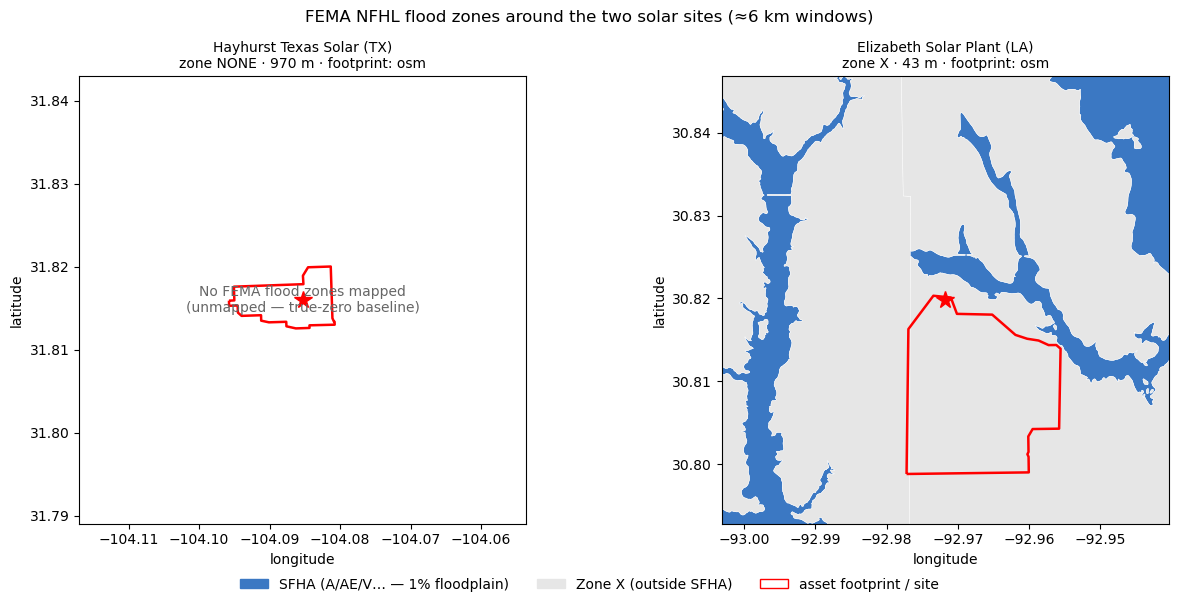

In [12]:

SFHA_Z = {"A", "AE", "AH", "AO", "AR", "A99", "V", "VE"}


def zone_color(z):
    if z in SFHA_Z:
        return "#3b78c3"   # SFHA — blue
    if z == "X":
        return "#e6e6e6"   # outside SFHA — light grey
    return "#b0b0b0"


def fetch_zone_polys(lat, lon, km=4):
    dlat = km * 1000 / 111_320.0
    dlon = km * 1000 / (111_320.0 * math.cos(math.radians(lat)))
    env = f"{lon-dlon},{lat-dlat},{lon+dlon},{lat+dlat}"
    p = {"geometry": env, "geometryType": "esriGeometryEnvelope", "inSR": 4326, "outSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE,ZONE_SUBTY",
         "returnGeometry": "true", "f": "geojson"}
    try:
        gj = cget(NFHL, p)
        if gj.get("features"):
            return gpd.GeoDataFrame.from_features(gj["features"], crs=4326)
    except Exception as e:
        print("  zone fetch error:", str(e)[:50])
    return gpd.GeoDataFrame({"FLD_ZONE": []}, geometry=[], crs=4326)


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (_, row) in zip(axes, sites.iterrows()):
    zg = fetch_zone_polys(row["lat"], row["lon"], km=4)
    if len(zg):
        zg.plot(ax=ax, color=zg["FLD_ZONE"].map(zone_color), edgecolor="white", linewidth=0.3)
    else:
        ax.text(0.5, 0.5, "No FEMA flood zones mapped\n(unmapped — true-zero baseline)",
                transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#666")
    gsites[gsites["eia"] == row["eia"]].boundary.plot(ax=ax, color="red", linewidth=1.8)
    ax.plot(row["lon"], row["lat"], marker="*", color="red", ms=13)
    ax.set_aspect(1 / math.cos(math.radians(row["lat"])))
    # pin both panels to the same fixed window around each site (zone polygons can be basin-sized)
    win_km = 3.0
    dla = win_km * 1000 / 111_320.0
    dlo = win_km * 1000 / (111_320.0 * math.cos(math.radians(row["lat"])))
    ax.set_xlim(row["lon"] - dlo, row["lon"] + dlo)
    ax.set_ylim(row["lat"] - dla, row["lat"] + dla)
    ax.set_title(f"{row['name']} ({row['state']})\nzone {row['fld_zone']} · {row['elev_mean_m']:.0f} m · footprint: {row['geometry_source']}", fontsize=10)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.ticklabel_format(useOffset=False, style="plain")

handles = [mpatches.Patch(color="#3b78c3", label="SFHA (A/AE/V… — 1% floodplain)"),
           mpatches.Patch(color="#e6e6e6", label="Zone X (outside SFHA)"),
           mpatches.Patch(facecolor="none", edgecolor="red", label="asset footprint / site")]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("FEMA NFHL flood zones around the two solar sites (≈6 km windows)", fontsize=12)
fig.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()

## 4 · Field dictionary (what each layer is, its datum/units, its base)

*Basics-spot-on:* every layer named with value · meaning · datum · units · source — so nothing is used blind.

In [13]:
field_dict = pd.DataFrame([
    ["ground_elevation", "3DEP DEM, sampled over footprint", "metres", "NAVD88 (vertical)", "USGS 3DEP ImageServer getSamples"],
    ["footprint", "asset boundary (or circle fallback)", "km² / polygon", "EPSG:4326 (area via 5070)", "enriched→OSM→circle seam"],
    ["fld_zone", "FEMA SFHA flood zone (A/AE/X/…)", "categorical", "NFHL", "FEMA NFHL layer 28"],
    ["static_bfe", "Base Flood Elevation (if determined)", "feet", "NAVD88", "FEMA NFHL (null in Zone A)"],
    ["depth_at_RP", "flood depth at return period — built in M1", "metres", "above ground", "FEMA BLE raster ble_image + NLDI→NSS Q(T) (JD-FL-6)"],
], columns=["field", "meaning", "units", "datum/ref", "source"])
print(field_dict.to_string(index=False))

           field                                    meaning         units                 datum/ref                                              source
ground_elevation           3DEP DEM, sampled over footprint        metres         NAVD88 (vertical)                    USGS 3DEP ImageServer getSamples
       footprint        asset boundary (or circle fallback) km² / polygon EPSG:4326 (area via 5070)                            enriched→OSM→circle seam
        fld_zone            FEMA SFHA flood zone (A/AE/X/…)   categorical                      NFHL                                  FEMA NFHL layer 28
      static_bfe       Base Flood Elevation (if determined)          feet                    NAVD88                          FEMA NFHL (null in Zone A)
     depth_at_RP flood depth at return period — built in M1        metres              above ground FEMA BLE raster ble_image + NLDI→NSS Q(T) (JD-FL-6)


## 5 · Coupling-structure preview — what depth will plug into

The M2 site-conditioned coupling is **`depth_at_asset = water_surface_elevation(event) − ground_elevation`**.
We now hold `ground_elevation` (the DEM distribution above); the `water_surface_elevation` per return period is
built in **M1** from the **FEMA BLE** raster (JD-FL-6). The preview below shows the *structure* — where depth enters — it
does **not** invent a depth.

In [14]:
for _, r in sites.iterrows():
    print(f"{r['name']} ({r['role']}):")
    print(f"   ground_elev ≈ {r['elev_mean_m']:.1f} m (NAVD88), footprint relief {r['elev_relief_m']:.1f} m, FEMA zone {r['fld_zone']}")
    print(f"   depth_at_asset = WSE(event) − ground_elev   ← WSE from FEMA BLE raster (built in M1, JD-FL-6)")
    print(f"   → flat relief ({r['elev_relief_m']:.1f} m) means once WSE is known, the whole footprint floods to ~uniform depth\n"
          if r['elev_relief_m'] < 3 else
          f"   → {r['elev_relief_m']:.1f} m relief means depth will vary across the footprint (micro-topography matters)\n")

Hayhurst Texas Solar (baseline (low-flood)):
   ground_elev ≈ 970.0 m (NAVD88), footprint relief 17.8 m, FEMA zone NONE
   depth_at_asset = WSE(event) − ground_elev   ← WSE from FEMA BLE raster (built in M1, JD-FL-6)
   → 17.8 m relief means depth will vary across the footprint (micro-topography matters)

Elizabeth Solar Plant (proving (high-flood)):
   ground_elev ≈ 42.8 m (NAVD88), footprint relief 15.5 m, FEMA zone X
   depth_at_asset = WSE(event) − ground_elev   ← WSE from FEMA BLE raster (built in M1, JD-FL-6)
   → 15.5 m relief means depth will vary across the footprint (micro-topography matters)



## 6 · Known-answer checks (basics-spot-on)

- **Hayhurst** — high desert, dry: high elevation, **not** SFHA.
- **Elizabeth (high)** — Louisiana alluvial plain: **low elevation** and **flat** (floodplain signature). Its
  *centroid* is zone X, but the footprint straddles the SFHA and BLE confirms real flood depth (M1).

In [15]:
hay = sites[sites.eia == 66880].iloc[0]
bay = sites[sites.eia == 66111].iloc[0]   # Elizabeth Solar (high)
assert hay["elev_mean_m"] > 500 and hay["fld_zone"] not in {"A", "AE", "AH", "AO", "V", "VE"}, "Hayhurst KA fail"
assert bay["elev_mean_m"] < 100, "high-site KA fail (should be low-lying alluvial plain)"
assert bay["elev_relief_m"] < hay["elev_relief_m"], "expected the floodplain site flatter than the desert site"
print(f"✓ Hayhurst: {hay['elev_mean_m']:.0f} m, zone {hay['fld_zone']} (dry, high)")
print(f"✓ {bay['name']}: {bay['elev_mean_m']:.0f} m, zone {bay['fld_zone']}, relief {bay['elev_relief_m']:.1f} m (low, flat; SFHA in footprint, BLE depth in M1)")
print("✓ all known-answer checks pass — the low-vs-high contrast holds on real DEM + FEMA data.")

✓ Hayhurst: 970 m, zone NONE (dry, high)
✓ Elizabeth Solar Plant: 43 m, zone X, relief 15.5 m (low, flat; SFHA in footprint, BLE depth in M1)
✓ all known-answer checks pass — the low-vs-high contrast holds on real DEM + FEMA data.


## 7 · Persist the M0 context manifest

In [16]:
manifest = {
    "peril": "flood", "sub_peril": "riverine", "event_family_id": None, "layer": "M0",
    "depth_source": "FEMA BLE raster + NLDI→NSS Q(T), built in M1 (JD-FL-6)",
    "optional_swaps": {
        "depth": "commercial Fathom / First Street depth grid (future)",
        "footprint": "enriched-registry polygon (real OSM polygons used now)",
    },
    "field_dictionary": field_dict.to_dict(orient="records"),
    "sites": json.loads(sites.drop(columns=[c for c in sites.columns if c == "geometry"], errors="ignore").to_json(orient="records")),
}
(OUT / "flood_solar_m0_dem_context.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_solar_m0_dem_context.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_m0_dem_context.json


## Findings & what's next

- **Real, public, done:** ground elevation (3DEP DEM) + FEMA flood zone at both inland sites — a clean low-vs-high
  contrast (Hayhurst ~970 m / dry / not-SFHA vs Elizabeth ~43 m / flat / SFHA-in-footprint). The DEM is the *asset*
  half of the flood coupling, captured for real.
- **Geometry is real, not a circle:** both sites resolved to **real OSM `power=plant` polygons** (Hayhurst
  0.735 km² · Elizabeth 3.911 km²) — no capacity-radius fallback needed; the boundary *seam* keeps the
  enriched-registry polygon a one-place swap if ever wanted.
- **Depth is sourced, not deferred:** riverine depth is **FEMA BLE** (HEC-RAS-quality, NAVD88) at Elizabeth —
  `WSE − ground` is feet-scale and SFHA-confirmed; Hayhurst reads **true zero** (the null-vs-zero trap holds). BLE
  **supersedes the earlier Fathom plan** ([JD-FL-6](../../../docs/plans/flood/decisions.md)).
- **Next:** part 3 screens the Gulf/Atlantic fleet for the **coastal** site (Discovery) and part 4 registers the
  **all-three** site (LA3); then **M1 (catalog)** assembles the per-sub-peril depth field — riverine off the **BLE
  depth raster** (`ble_image`) + lower-RP densification (JD-FL-8), pluvial Atlas-14 runoff, coastal SLOSH — each
  `sub_peril`-keyed with the reserved `event_family_id` (JD-FL-4).

## ═══ part 3/4 ═══  Flood · Coastal `[C]` × Solar — M0: surge screen → the coastal site (Discovery)

**Magnitude metric:** the screening metric is the **surge-onset hurricane category** (NOAA CFEM / SLOSH-derived);
per-storm surge **depth (ft above ground)** is the M1 hazard input.

**Data source:** **EIA-860** 2024 (cached, same product part 1 uses) · NOAA **CFEM** Coastal Flood Hazard
Composite (SLOSH-derived surge onset, by category) · **OSM** Overpass `power=plant` footprint (circle fallback).

**What this notebook does:** screens the Gulf/Atlantic utility-scale solar fleet by surge onset and locks the
coastal proving site — **Discovery Solar Center** (EIA 63109, Cape Canaveral FL, Cat-1 onset) — against the
Hayhurst dry control, fetches its geometry, and emits `flood_solar_coastal_m0_sites.json` for the unified
M1/coastal catalog.

In [17]:
RAW = ROOT / "data" / "flood" / "raw"
OUT = ROOT / "data" / "flood"
RAW.mkdir(parents=True, exist_ok=True)

# --- tiny HTTP file-cache (deterministic, flaky-endpoint-robust re-runs) ---
_CACHE = RAW / "http_cache"; _CACHE.mkdir(parents=True, exist_ok=True)
def cget(url, params=None, timeout=40):
    key = hashlib.md5(("G" + url + json.dumps(params, sort_keys=True, default=str)).encode()).hexdigest()
    f = _CACHE / (key + ".json")
    if f.exists():
        return json.loads(f.read_text())
    j = requests.get(url, params=params, timeout=timeout).json()
    f.write_text(json.dumps(j)); return j
print("repo root:", ROOT)

repo root: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling


### 1 · EIA-860 operating solar fleet (cached — same product 01 uses)

In [18]:
EIA_URL = "https://www.eia.gov/electricity/data/eia860/xls/eia8602024.zip"
EIA_ZIP = RAW / "eia860_2024.zip"
if not EIA_ZIP.exists():
    print("downloading EIA-860 2024 …")
    EIA_ZIP.write_bytes(requests.get(EIA_URL, timeout=180).content)
with zipfile.ZipFile(EIA_ZIP) as z:
    plant = pd.read_excel(z.open("2___Plant_Y2024.xlsx"), skiprows=1)
    solar = pd.read_excel(z.open("3_3_Solar_Y2024.xlsx"), skiprows=1)
solar["Nameplate Capacity (MW)"] = pd.to_numeric(solar["Nameplate Capacity (MW)"], errors="coerce")
cap = solar[solar["Status"] == "OP"].groupby("Plant Code")["Nameplate Capacity (MW)"].sum().rename("solar_mw")
fleet = (plant.set_index("Plant Code").join(cap, how="inner").reset_index()
              .dropna(subset=["Latitude", "Longitude"]))
fleet = fleet[["Plant Code", "Plant Name", "State", "County", "solar_mw", "Latitude", "Longitude"]]
print(f"operating solar plants nationwide: {len(fleet):,}  |  total {fleet['solar_mw'].sum():,.0f} MW")

# Gulf + Atlantic coastal states (the surge-relevant fleet; the composite gates non-coastal points to NoData)
COAST_STATES = ["TX", "LA", "MS", "AL", "FL", "GA", "SC", "NC", "VA"]
UTIL_MW = 20.0
cand = (fleet[fleet["State"].isin(COAST_STATES) & (fleet["solar_mw"] >= UTIL_MW)]
        .sort_values("solar_mw", ascending=False).reset_index(drop=True))
print(f"Gulf/Atlantic utility-scale (≥{UTIL_MW:.0f} MW) solar candidates: {len(cand)}")

operating solar plants nationwide: 6,489  |  total 124,301 MW
Gulf/Atlantic utility-scale (≥20 MW) solar candidates: 513


### 2 · Surge screen — NOAA Coastal Flood Hazard Composite (SLOSH-derived, by category)
onset_cat = lowest hurricane category whose surge reaches the site (lower = more exposed)

In [19]:
CFEM = ("https://www.coast.noaa.gov/arcgis/rest/services/FloodExposureMapper/"
        "CFEM_CoastalFloodHazardComposite/MapServer/identify")
def surge_screen(lat, lon):
    """→ (onset_cat:int|None, surge_cats:list[int], descr:str). None = no SLOSH surge / inland (NoData)."""
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "sr": 4326, "tolerance": 2,
         "mapExtent": f"{lon-.05},{lat-.05},{lon+.05},{lat+.05}", "imageDisplay": "600,600,96",
         "layers": "all", "returnGeometry": "false", "f": "json"}
    try:
        r = cget(CFEM, p)
        for res in r.get("results", []):
            d = res.get("attributes", {}).get("Raster.DESCRPTN", "") or ""
            if "Hurricane Category" in d:
                cats = [int(x) for x in re.findall(r"\d", d.split("Hurricane Category")[1])]
                return (min(cats) if cats else None), sorted(set(cats)), d
        return None, [], "no-surge/NoData"
    except Exception as e:
        return None, [], f"ERR:{str(e)[:30]}"

scr = cand.copy()
oc, scats, desc = [], [], []
for _, r in scr.iterrows():
    a, b, c = surge_screen(r["Latitude"], r["Longitude"])
    oc.append(a); scats.append(b); desc.append(c)
scr["onset_cat"] = oc
scr["surge_cats"] = scats
scr["surge_descr"] = desc
scr["surge_exposed"] = scr["onset_cat"].notna()
scr["depth_source"] = "NOAA_CFEM_composite"   # JD-FL-14 source tag; raster swap = US_SLOSH_MOM_Inundation_v4

exposed = scr[scr["surge_exposed"]].sort_values(["onset_cat", "solar_mw"], ascending=[True, False])
print(f"\nsurge-exposed coastal solar: {len(exposed)}/{len(scr)}")
print(exposed[["Plant Name", "State", "County", "solar_mw", "onset_cat"]].head(20).to_string(index=False))


surge-exposed coastal solar: 16/513
                         Plant Name State           County  solar_mw  onset_cat
             Discovery Solar Center    FL          Brevard      74.5        1.0
                  Big Bend II Solar    FL     Hillsborough      45.8        1.0
                   Camden Solar LLC    NC           Camden      20.0        1.0
               St. James Solar (LA)    LA         St James      20.0        1.0
        Bay Trail Solar Power Plant    FL           Citrus      74.9        2.0
                 Summit Farms Solar    NC        Currituck      62.4        2.0
                    FL Solar 4, LLC    FL             Leon      42.0        2.0
                       Shawboro PV1    NC        Currituck      20.0        2.0
              Albemarle Beach Solar    NC       Washington     130.2        3.0
               Oak Trail Solar, LLC    NC        Currituck     100.0        3.0
                Wilkinson Solar LLC    NC         Beaufort      80.6        3.0
   

### 3 · Pick sites — high = most-exposed sizable FL/Atlantic plant (in hurricane footprint); low = Hayhurst

In [20]:
HIGH_EIA = 63109   # Discovery Solar Center, Brevard Co. FL (Cat-1 onset, 74 MW, Atlantic coast — Cape Canaveral)
high = scr[scr["Plant Code"] == HIGH_EIA].iloc[0]
print(f"\n→ HIGH (proving): {high['Plant Name']} (EIA {HIGH_EIA}), {high['State']} {high['County']}, "
      f"{high['solar_mw']:.0f} MW, onset Cat-{int(high['onset_cat'])}, surge cats {high['surge_cats']}")

# Hayhurst baseline — confirm structural zero via the same screen (expect None/inland)
HAY = dict(name="Hayhurst Texas Solar", eia=66880, state="TX", county="Culberson",
           lat=31.815992, lon=-104.085297, solar_mw=24.8)
hay_oc, hay_cats, hay_desc = surge_screen(HAY["lat"], HAY["lon"])
print(f"→ LOW (baseline): {HAY['name']} — surge_screen={hay_oc} ({hay_desc[:30]}) → structural zero (no coastline)")

def cap_radius_m(mw):
    return 69.0 * math.sqrt(mw * 1.3)   # capacity→radius proxy (DC≈AC·1.3); the hail/wildfire fallback


→ HIGH (proving): Discovery Solar Center (EIA 63109), FL Brevard, 74 MW, onset Cat-1, surge cats [1, 2, 3]
→ LOW (baseline): Hayhurst Texas Solar — surge_screen=None (no-surge/NoData) → structural zero (no coastline)


### 4 · High-site geometry — real OSM polygon (Overpass) with circle fallback (mirrors 01/02)

In [21]:
OVERPASS = "https://maps.mail.ru/osm/tools/overpass/api/interpreter"   # reachable mirror (per flood 02)
def osm_polygon_wkt(lat, lon, r_m, name_hint=""):
    q = (f'[out:json][timeout:40];(way["power"="plant"](around:{r_m*2.5},{lat},{lon});'
         f'way["plant:source"="solar"](around:{r_m*2.5},{lat},{lon});'
         f'relation["power"="plant"](around:{r_m*2.5},{lat},{lon}););out geom;')
    try:
        j = requests.post(OVERPASS, data=q, timeout=60).json()
        best = None
        for el in j.get("elements", []):
            geom = el.get("geometry") or (el.get("members", [{}])[0].get("geometry") if el.get("members") else None)
            if not geom or len(geom) < 4:
                continue
            pts = [(p["lon"], p["lat"]) for p in geom]
            # crude area proxy (shoelace in deg²) to take the largest nearby plant polygon
            area = abs(sum(pts[i][0]*pts[i+1][1]-pts[i+1][0]*pts[i][1] for i in range(len(pts)-1)))
            if best is None or area > best[0]:
                best = (area, pts)
        if best:
            ring = best[1]
            if ring[0] != ring[-1]:
                ring = ring + [ring[0]]
            return "POLYGON((" + ", ".join(f"{x} {y}" for x, y in ring) + "))", "osm_plant_polygon"
    except Exception as e:
        print("  overpass failed:", str(e)[:60])
    # fallback: circle of capacity-radius
    r_deg = r_m / 111_320.0
    ring = [(lon + r_deg/math.cos(math.radians(lat))*math.cos(t), lat + r_deg*math.sin(t))
            for t in np.linspace(0, 2*math.pi, 49)]
    return "POLYGON((" + ", ".join(f"{x} {y}" for x, y in ring) + "))", "circle_fallback"

hr = cap_radius_m(float(high["solar_mw"]))
high_wkt, high_geom_src = osm_polygon_wkt(float(high["Latitude"]), float(high["Longitude"]), hr, high["Plant Name"])
print(f"high-site geometry: {high_geom_src} (cap-radius {hr:.0f} m)")

high-site geometry: osm_plant_polygon (cap-radius 679 m)


### 5 · Emit M0 coastal manifest + screen CSV

In [22]:
sites = {
    "peril": "flood", "sub_peril": "coastal", "asset": "solar", "layer": "M0",
    "event_family_id": None,   # reserved — stamped in M1/coastal from the hurricane cross-link (JD-FL-4)
    "source": "flood/m0_input_data/01_solar_sites",
    "screen": {
        "population": "EIA-860 2024 operating solar fleet",
        "region": "Gulf + Atlantic coastal states (TX LA MS AL FL GA SC NC VA)",
        "metric": "surge onset hurricane category — NOAA Coastal Flood Hazard Composite (SLOSH-derived, by category)",
        "depth_source": "NOAA_CFEM_composite",
        "depth_source_swap": "US_SLOSH_MOM_Inundation_v4 raster (JD-FL-14) — continuous depth-in-feet per category",
        "n_candidates": int(len(scr)), "n_surge_exposed": int(scr["surge_exposed"].sum()),
        "min_mw": UTIL_MW,
    },
    "decisions": ["JD-FL-13 (sites)", "JD-FL-14 (SLOSH-only V1, source-tagged)", "JD-FL-12 (wind+surge combine, M4)"],
    "sites": [
        {"role": "baseline (low-surge)", "name": HAY["name"], "eia": HAY["eia"], "state": HAY["state"],
         "county": HAY["county"], "lat": HAY["lat"], "lon": HAY["lon"], "solar_mw": HAY["solar_mw"],
         "onset_cat": None, "surge_cats": [], "surge_exposed": False,
         "note": "structural zero — inland desert, no coastline; reused cross-peril baseline (JD-FL-13)",
         "footprint_r_m": round(cap_radius_m(HAY["solar_mw"]), 1)},
        {"role": "proving (high-surge)", "name": high["Plant Name"], "eia": int(HIGH_EIA),
         "state": high["State"], "county": high["County"], "lat": float(high["Latitude"]),
         "lon": float(high["Longitude"]), "solar_mw": float(high["solar_mw"]),
         "onset_cat": int(high["onset_cat"]), "surge_cats": [int(c) for c in high["surge_cats"]],
         "surge_exposed": True, "geometry_source": high_geom_src, "boundary_wkt": high_wkt,
         "footprint_r_m": round(hr, 1),
         "note": "Atlantic coast (Cape Canaveral); in hurricane catalog footprint → exercises JD-FL-12 combine"},
    ],
}
(OUT / "flood_solar_coastal_m0_sites.json").write_text(json.dumps(sites, indent=2))
csv_cols = ["Plant Code", "Plant Name", "State", "County", "solar_mw", "Latitude", "Longitude",
            "onset_cat", "surge_exposed", "surge_descr", "depth_source"]
scr.sort_values(["surge_exposed", "onset_cat", "solar_mw"], ascending=[False, True, False])[csv_cols].to_csv(
    OUT / "flood_solar_coastal_m0_site_screen.csv", index=False)
print("\nwrote:", OUT / "flood_solar_coastal_m0_sites.json")
print("wrote:", OUT / "flood_solar_coastal_m0_site_screen.csv")




wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_coastal_m0_sites.json
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_coastal_m0_site_screen.csv


## ═══ part 4/4 ═══  Flood · all sub-perils `[R/F/C]` × Solar — M0: the all-three solar site (LA3 West Baton Rouge)

**Magnitude metric:** the M0 **screening metrics** are riverine **NFHL zone** (SFHA membership), coastal
**surge-onset hurricane category** (CFEM/SLOSH), and pluvial Atlas-14 coverage (automatic); per-sub-peril depth (ft
above ground) is the M1/M2 hazard input.

**Data source:** **EIA-860** 2024 (location + capacity; cached zip, same product as 01/03) · FEMA **NFHL** layer 28
(riverine zone) · NOAA **CFEM** Coastal Flood Hazard Composite (surge onset) · **OSM** Overpass `power=plant`
footprint polygon (capacity-radius circle fallback).

**What this notebook does:** adds the **all-three** solar site so solar's M2/M3/M4 can unify (JD-FL-17, the solar
analogue of `06`/Amazon). The site is **LA3 West Baton Rouge Solar Facility**
(EIA 61646, West Baton Rouge Parish LA) — a genuine compound-flood asset carrying all three sub-perils at one
location: riverine Zone A (Mississippi floodplain, FEMA **BLE** "Lower Grand" study → `ble_image` like Elizabeth) +
coastal SLOSH surge Cat-3 onset (Gulf surge propagating up-river) + pluvial Atlas 14. It reads the EIA-860 location
+ capacity, screens the NFHL riverine zone and CFEM surge onset, fetches the OSM footprint polygon (the bbox BLE
needs), runs known-answer checks (Zone A riverine + surge-exposed), and registers LA3 in the three solar rosters so
the unified M1s pick it up — `flood_solar_m0_sites.json` (inland: riverine+pluvial), `flood_solar_m0_dem_context.json` (the
`boundary_wkt`), and `flood_solar_coastal_m0_sites.json` (coastal); re-running is safe (any prior LA3 entry is replaced).
It does not sample depth (M1/M2). Run order: after `01`/`02`/`03`.

In [23]:

OUT = ROOT / "data" / "flood"; RAW = OUT / "raw"; _C = RAW / "http_cache"; _C.mkdir(parents=True, exist_ok=True)
def cget(url, p, t=40):
    k = hashlib.md5((url + json.dumps(p, sort_keys=True, default=str)).encode()).hexdigest(); f = _C / (k + ".json")
    if f.exists(): return json.loads(f.read_text())
    j = requests.get(url, params=p, timeout=t).json(); f.write_text(json.dumps(j)); return j

EIA_CODE = 61646; NAME = "LA3 West Baton Rouge Solar Facility"
NFHL = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28/query"
CFEM = ("https://www.coast.noaa.gov/arcgis/rest/services/FloodExposureMapper/"
        "CFEM_CoastalFloodHazardComposite/MapServer/identify")
OVERPASS = "https://maps.mail.ru/osm/tools/overpass/api/interpreter"
SFHA = {"A", "AE", "AH", "AO", "AR", "A99", "V", "VE"}
print("repo root:", ROOT)

repo root: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling


## 1 · EIA-860 location + capacity (cached zip, same product 01/03 use)

In [24]:
with zipfile.ZipFile(RAW / "eia860_2024.zip") as z:
    plant = pd.read_excel(z.open("2___Plant_Y2024.xlsx"), skiprows=1)
    solar = pd.read_excel(z.open("3_3_Solar_Y2024.xlsx"), skiprows=1)
solar["Nameplate Capacity (MW)"] = pd.to_numeric(solar["Nameplate Capacity (MW)"], errors="coerce")
mw = float(solar[(solar["Plant Code"] == EIA_CODE) & (solar["Status"] == "OP")]["Nameplate Capacity (MW)"].sum())
pr = plant[plant["Plant Code"] == EIA_CODE].iloc[0]
LAT, LON, STATE, COUNTY = float(pr["Latitude"]), float(pr["Longitude"]), pr["State"], pr["County"]
print(f"{NAME} (EIA {EIA_CODE}): {STATE} {COUNTY} @ {LAT:.4f},{LON:.4f} · {mw:.0f} MW")

LA3 West Baton Rouge Solar Facility (EIA 61646): LA West Baton Rouge @ 30.4651,-91.3319 · 50 MW


## 2 · Exposures — riverine (NFHL zone), coastal (CFEM surge onset), pluvial (Atlas-14, automatic)

In [25]:
def zone_at(lat, lon):
    fs = cget(NFHL, {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "inSR": 4326,
                     "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE", "returnGeometry": "false", "f": "json"}).get("features", [])
    return fs[0]["attributes"]["FLD_ZONE"] if fs else "X"

def surge_screen(lat, lon):
    import re
    res = cget(CFEM, {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "sr": 4326, "tolerance": 2,
                      "mapExtent": f"{lon-.05},{lat-.05},{lon+.05},{lat+.05}", "imageDisplay": "600,600,96",
                      "layers": "all", "returnGeometry": "false", "f": "json"}).get("results", [])
    for x in res:
        d = x.get("attributes", {}).get("Raster.DESCRPTN", "") or ""
        if "Hurricane Category" in d:
            cats = [int(v) for v in re.findall(r"\d", d.split("Hurricane Category")[1])]
            return (min(cats) if cats else None), sorted(set(cats))
    return None, []

zone = zone_at(LAT, LON); in_sfha = zone in SFHA
onset_cat, surge_cats = surge_screen(LAT, LON)
print(f"  riverine: NFHL zone {zone} (in_sfha={in_sfha})")
print(f"  coastal : surge onset Cat-{onset_cat}, categories {surge_cats}")
print(f"  pluvial : Atlas-14 (LA covered) — no screen needed")

  riverine: NFHL zone A (in_sfha=True)
  coastal : surge onset Cat-3, categories [3]
  pluvial : Atlas-14 (LA covered) — no screen needed


## 3 · OSM footprint polygon (real geometry; circle fallback) — the BLE bbox + coastal footprint

In [26]:
def cap_radius_m(mw): return 69.0 * math.sqrt(max(mw, 1.0) * 1.3)
def osm_polygon_wkt(lat, lon, r_m):
    q = (f'[out:json][timeout:40];(way["power"="plant"](around:{r_m*2.5},{lat},{lon});'
         f'way["plant:source"="solar"](around:{r_m*2.5},{lat},{lon});'
         f'relation["power"="plant"](around:{r_m*2.5},{lat},{lon}););out geom;')
    try:
        j = requests.post(OVERPASS, data=q, timeout=60).json(); best = None
        for el in j.get("elements", []):
            geom = el.get("geometry") or (el.get("members", [{}])[0].get("geometry") if el.get("members") else None)
            if not geom or len(geom) < 4: continue
            pts = [(p["lon"], p["lat"]) for p in geom]
            area = abs(sum(pts[i][0]*pts[i+1][1]-pts[i+1][0]*pts[i][1] for i in range(len(pts)-1)))
            if best is None or area > best[0]: best = (area, pts)
        if best:
            ring = best[1] + ([best[1][0]] if best[1][0] != best[1][-1] else [])
            return "POLYGON((" + ", ".join(f"{x} {y}" for x, y in ring) + "))", "osm_plant_polygon"
    except Exception as e:
        print("  overpass failed:", str(e)[:60])
    r_deg = r_m / 111_320.0
    ring = [(lon + r_deg/math.cos(math.radians(lat))*math.cos(t), lat + r_deg*math.sin(t)) for t in np.linspace(0, 2*math.pi, 49)]
    return "POLYGON((" + ", ".join(f"{x} {y}" for x, y in ring) + "))", "circle_fallback"

R_M = cap_radius_m(mw)
boundary_wkt, geom_src = osm_polygon_wkt(LAT, LON, R_M)
poly = _wkt.loads(boundary_wkt)
footprint_km2 = float(gpd.GeoSeries([poly], crs=4326).to_crs(5070).area.iloc[0]) / 1e6
print(f"  geometry: {geom_src} (cap-radius {R_M:.0f} m, {footprint_km2:.2f} km²)")

  geometry: osm_plant_polygon (cap-radius 556 m, 0.61 km²)


## 4 · Known-answer checks + register LA3 in the solar rosters (re-run-safe upsert)

In [27]:
assert in_sfha and onset_cat is not None, "LA3 must be all-three (Zone A riverine + surge-exposed)"
assert mw > 10 and footprint_km2 > 0, "real utility-scale plant with geometry"
print(f"✓ LA3 all-three: riverine zone {zone} + coastal Cat-{onset_cat} + pluvial (Atlas-14); {mw:.0f} MW, {footprint_km2:.2f} km²")

def upsert(path, entry, key="eia"):
    d = json.loads((OUT / path).read_text())
    d["sites"] = [s for s in d["sites"] if s.get(key) != entry[key]] + [entry]
    (OUT / path).write_text(json.dumps(d, indent=2, default=str)); return len(d["sites"])

ROLE = "all-three (coastal+riverine+pluvial)"
# (a) inland roster (riverine + pluvial M1 read this)
n_inland = upsert("flood_solar_m0_sites.json", {
    "role": ROLE, "name": NAME, "eia": EIA_CODE, "state": STATE, "county": COUNTY, "lat": LAT, "lon": LON,
    "solar_mw": round(mw, 1), "zone": zone, "in_sfha": in_sfha, "sfha_in_buffer": in_sfha, "footprint_r_m": round(R_M)})
# (b) DEM context — the boundary_wkt BLE needs (ble_image); elev stats are informational, null for now
n_dem = upsert("flood_solar_m0_dem_context.json", {
    "role": ROLE, "name": NAME, "eia": EIA_CODE, "state": STATE, "county": COUNTY, "lat": LAT, "lon": LON,
    "solar_mw": round(mw, 1), "zone": zone, "in_sfha": in_sfha, "sfha_in_buffer": in_sfha, "footprint_r_m": round(R_M),
    "geometry_source": geom_src, "footprint_km2": round(footprint_km2, 3), "boundary_wkt": boundary_wkt,
    "elev_min_m": None, "elev_mean_m": None, "elev_max_m": None, "elev_relief_m": None, "elev_std_m": None,
    "dem_n": None, "fld_zone": zone, "zone_subty": None, "static_bfe": None,
    "note": "ble_image riverine (BLE Lower Grand) — elev stats not needed (BLE depth is above-ground); coastal+pluvial too"})
# (c) coastal roster (coastal M1 reads this)
n_coa = upsert("flood_solar_coastal_m0_sites.json", {
    "role": "proving (all-three)", "name": NAME, "eia": EIA_CODE, "state": STATE, "county": COUNTY, "lat": LAT, "lon": LON,
    "solar_mw": round(mw, 1), "onset_cat": int(onset_cat), "surge_cats": [int(c) for c in surge_cats], "surge_exposed": True,
    "geometry_source": geom_src, "boundary_wkt": boundary_wkt, "footprint_r_m": round(R_M),
    "note": "JD-FL-17 all-three solar site — Gulf surge up the Mississippi; pairs with riverine+pluvial at the SAME site"})
print(f"registered LA3 → flood_solar_m0_sites.json ({n_inland} sites) · flood_solar_m0_dem_context.json ({n_dem}) · flood_solar_coastal_m0_sites.json ({n_coa})")

✓ LA3 all-three: riverine zone A + coastal Cat-3 + pluvial (Atlas-14); 50 MW, 0.61 km²
registered LA3 → flood_solar_m0_sites.json (3 sites) · flood_solar_m0_dem_context.json (3) · flood_solar_coastal_m0_sites.json (3)


## Findings → next

- **LA3 West Baton Rouge is the all-three solar site** (riverine Zone A / BLE Lower Grand · coastal Cat-3 surge ·
  pluvial Atlas-14), registered in the three solar rosters so the unified M1s pick it up automatically.
- **Next:** add LA3 to **hurricane × solar** (the compound wind leg, per-storm per-subsystem DR on `event_family_id`),
  run flood M1 (riverine ble_image + pluvial + coastal) for LA3, then **unify solar M2/M3/M4** into one file each
  covering all three sub-perils in one notebook each (JD-FL-17).